# Currency Market Analysis (Path of Exile)

This project analyzes currency exchange data to identify:
- Market trends over time
- Relationships between currencies
- Outliers in valuation
- Clustering behavior of currencies

We focus on trades priced in Chaos Orbs, the standard trading currency.

## Setup and Libraries

We import libraries for:
- Data manipulation (pandas, numpy)
- Visualization (seaborn, matplotlib)
- Machine learning (scikit-learn)

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
#read data
df = pd.read_csv("Mercenaries.currency.csv", sep=";")
df.head()
df.shape
df.info()
df.describe()

#used for things later these are my column names
df.columns = [
    "League",
    "Date",
    "Get",
    "Pay",
    "Value",
    "Confidence"
]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43126 entries, 0 to 43125
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   League      43126 non-null  object 
 1   Date        43126 non-null  object 
 2   Get         43126 non-null  object 
 3   Pay         43126 non-null  object 
 4   Value       43126 non-null  float64
 5   Confidence  43126 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.0+ MB


## Data Filtering and Preprocessing

In this step, the dataset is cleaned and prepared for analysis. Since multiple currencies exist in the dataset, only transactions using **Chaos Orbs** are retained. Chaos Orbs are commonly considered the standard trading currency, making them ideal for normalization and consistent comparison.

The following preprocessing steps are performed:
- Filter the dataset to include only rows where the payment type is Chaos Orbs
- Convert the `Date` column into a proper datetime format for accurate sorting and grouping
- Extract time-based features such as **day**, **month**, and **week** to enable temporal analysis
- Compute the average exchange rate for each currency relative to Chaos Orbs

In [3]:
#Data-set filtering
df = df[df["Pay"] == "Chaos Orb"] #only using rows that are priced in chaos for normalization 
df.head()
len(df) #26906 rows priced in chaos

df["Date"] = pd.to_datetime(df["Date"]) #better for date storting

df.groupby("Get")["Value"].mean().sort_values(ascending=False) #Average exchange rate per currency

#date descriptions to group based on weeks/months and later early late league
df["Date"] = pd.to_datetime(df["Date"])
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week

## Exchange Rate Over Time

This section visualizes how the average exchange rate (in Chaos Orbs) changes over time.

The data is grouped by date and averaged to highlight overall trends, fluctuations, and market behavior.

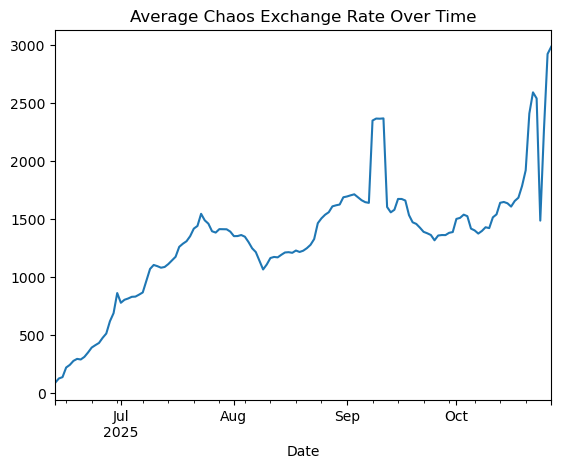

In [4]:
#exchange rate over time
df.groupby("Date")["Value"].mean().plot()
plt.title("Average Chaos Exchange Rate Over Time")
plt.show()

Here we can see that over time the average value of a chaos orb when compared to all other currencies rises. 

## Confidence Distribution

This histogram shows the distribution of trade confidence levels.

Most trades have high confidence, indicating generally reliable exchange data.

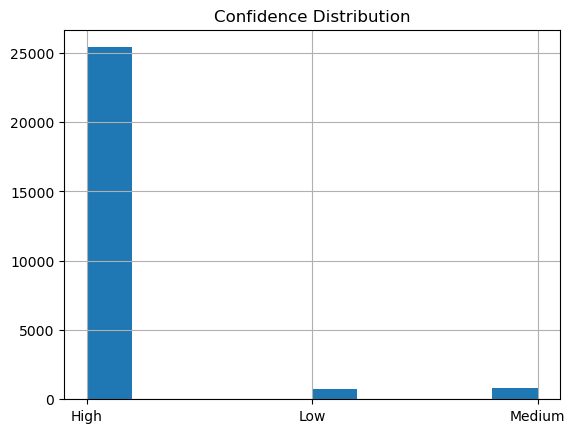

In [5]:
df["Confidence"].hist()
plt.title("Confidence Distribution")
plt.show()

## Data Preparation and Validation

In this step, categorical confidence levels are converted into numerical values for analysis. Selected features are then standardized to prepare for clustering.

Basic data validation checks confirm:
- No missing values
- No duplicate records

Additional insights include the number of unique currencies tracked and the low percentage of trades that are not marked as high confidence.

In [6]:
conf_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

#cleaning data to be used in different clusters
df["ConfidenceNum"] = df["Confidence"].map(conf_mapping)

features = df[["Value", "ConfidenceNum"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

print("\n\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("There are also no duplicate data points.\n")

num_currencies = df['Get'].nunique()
print("Number of different currencies tracked:", num_currencies, "\n")

total = len(df)
not_high = df[df['Confidence'] != 'High']
percent_not_high = (len(not_high) / total) * 100
print("Percentage of records NOT 'High' confidence:", percent_not_high, "%\n")



Missing values per column:
League           0
Date             0
Get              0
Pay              0
Value            0
Confidence       0
Day              0
Month            0
Week             0
ConfidenceNum    0
dtype: int64

Duplicate rows: 0
There are also no duplicate data points.

Number of different currencies tracked: 198 

Percentage of records NOT 'High' confidence: 5.578681335018212 %



## Currency Filtering and Correlation Setup

A subset of commonly traded base currencies is selected to reduce noise and improve readability in analysis.

The data is then reshaped into a pivot table, allowing for clearer comparisons over time. This structure is used to compute correlations between selected currencies, helping identify relationships and trends.

In [7]:
#these are commonly traded base currencies that i'm focusing on for some of the testing where having too many variables becomes cluttered
whitelist = [
    "Chromatic Orb",
    "Orb of Fusing",
    "Cartographer's Chisel",
    "Orb of Alchemy",
    "Exalted Orb",
    "Divine Orb",
    "Ancient Orb",
    "Fracturing Shard",
    "Grand Eldritch Ember",
    "Grand Eldritch Ichor",
    "Reflecting Mist",
    "Veiled Chaos Orb",
    "Mirror of Kalandra"
]

df_white = df[df["Get"].isin(whitelist)]

#pivot so some graphs are not too skewed and can be better read
pivot_white = df_white.pivot_table(
    index="Date",
    columns="Get",
    values="Value",
    aggfunc="mean"
)

# Reorder columns and rows to match whitelist order
pivot_white = pivot_white.reindex(columns=whitelist)
corr_white = pivot_white.corr()
corr_white = corr_white.reindex(index=whitelist, columns=whitelist)



# Discovery Question 1: Currency Correlation Trends

This section explores how different currencies move in relation to each other.

A correlation heatmap is used to identify:
- Positive correlations: currencies that increase or decrease together  
- Negative correlations: currencies that move in opposite directions  

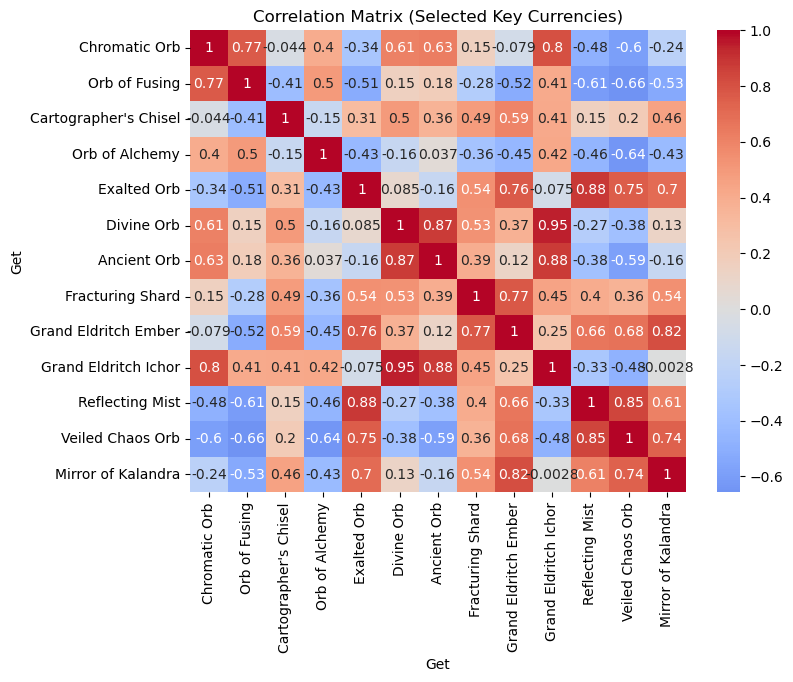

In [8]:
#Q1
plt.figure(figsize=(8,6))
sns.heatmap(corr_white, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Matrix (Selected Key Currencies)")
plt.show()

# Discovery Question 2: Early vs Late League Trends

This section compares currency values between the early and late stages of the league.

The dataset is split based on the median week, and average values are computed for each stage.

The analysis highlights:
- Overall changes in currency value over time
- Differences between early and late league markets
- Stage-based behavior for selected key currencies

A log-scaled bar chart is used to better visualize large differences between currencies.

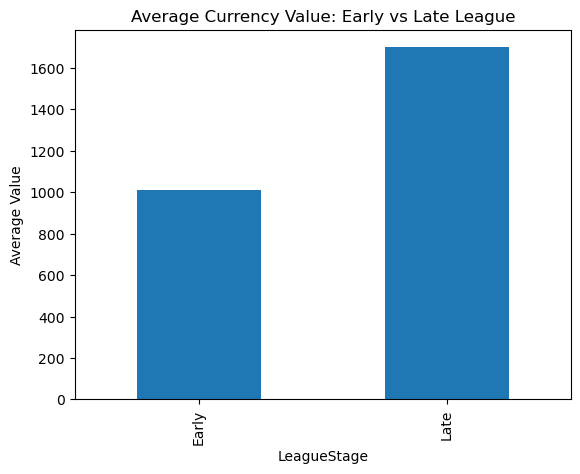

We can see that overall total value trends upwards in comparison to Chaos orbs over time


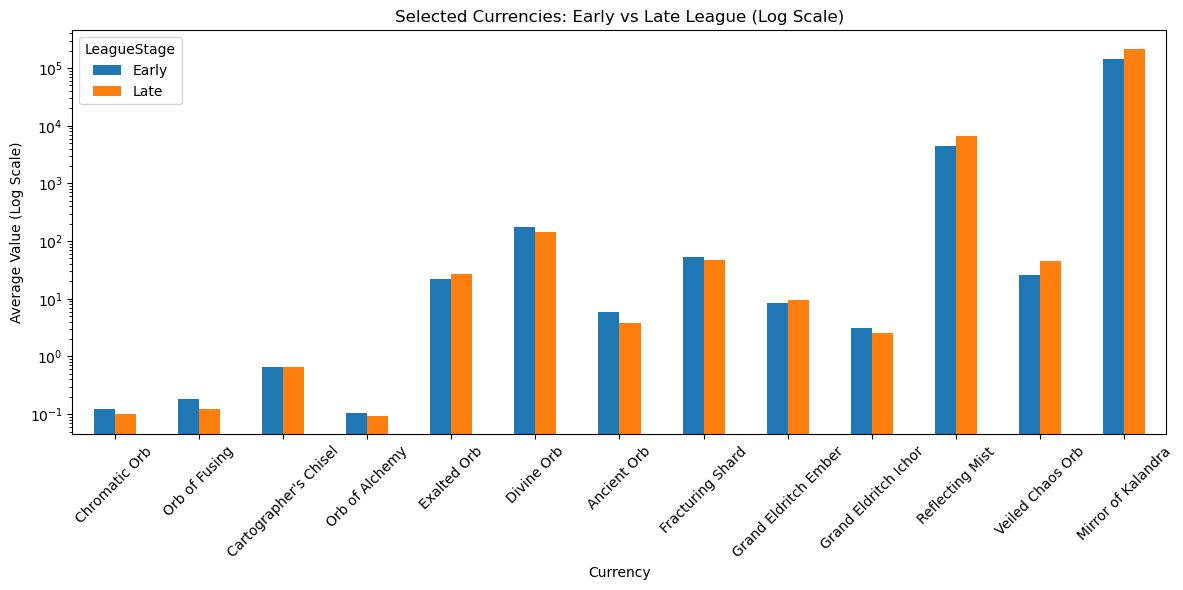

In [9]:
#Q2

# Define early and late league based on Week
median_week = df["Week"].median()

df["LeagueStage"] = df["Week"].apply(
    lambda x: "Early" if x <= median_week else "Late"
)
df["LeagueStage"].value_counts()
stage_avg = df.groupby("LeagueStage")["Value"].mean()
stage_avg.plot(kind="bar")
plt.title("Average Currency Value: Early vs Late League")
plt.ylabel("Average Value")
plt.show()

currency_stage = df.groupby(["Get","LeagueStage"])["Value"].mean().unstack()
currency_stage.head(10)

print("We can see that overall total value trends upwards in comparison to Chaos orbs over time")

selected = [c for c in whitelist if c in currency_stage.index]
ax = currency_stage.loc[selected].plot(kind="bar", figsize=(12,6))
plt.yscale("log")  # <-- This fixes the scaling issue
plt.title("Selected Currencies: Early vs Late League (Log Scale)")
plt.xlabel("Currency")
plt.ylabel("Average Value (Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 



# Discovery Question 3: Outliers and K-Means Clustering

## Optimal Number of Clusters (Elbow Method)

The elbow method is used to determine the optimal number of clusters for K-Means by analyzing how inertia changes as the number of clusters increases.

The optimal value of *k* is chosen at the point where the rate of decrease in inertia begins to slow, indicating diminishing returns from adding more clusters.

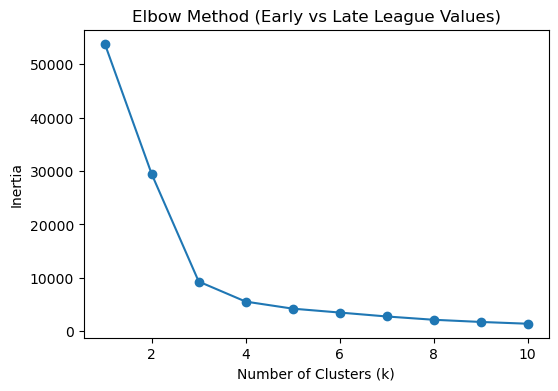

In [15]:
features = df[["Week", "Value"]].copy()

scaler = StandardScaler()
weekValue = scaler.fit_transform(features)

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(weekValue)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Early vs Late League Values)")
plt.show()

Here we can see that the sharp drop of intertia stops at 3 so we set our clustering to 3. 

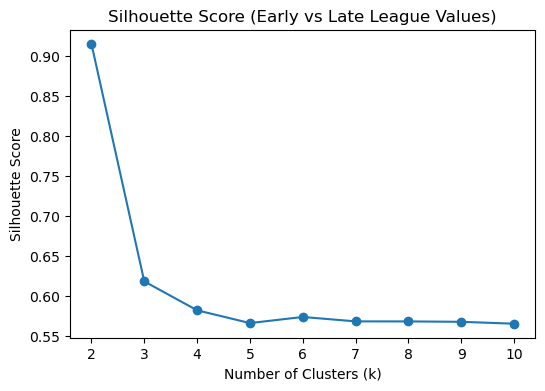

Best k based on silhouette: 2


In [16]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(weekValue)
    sil_scores.append(silhouette_score(weekValue, labels))

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (Early vs Late League Values)")
plt.show()

best_k = K[sil_scores.index(max(sil_scores))]
print("Best k based on silhouette:", best_k)

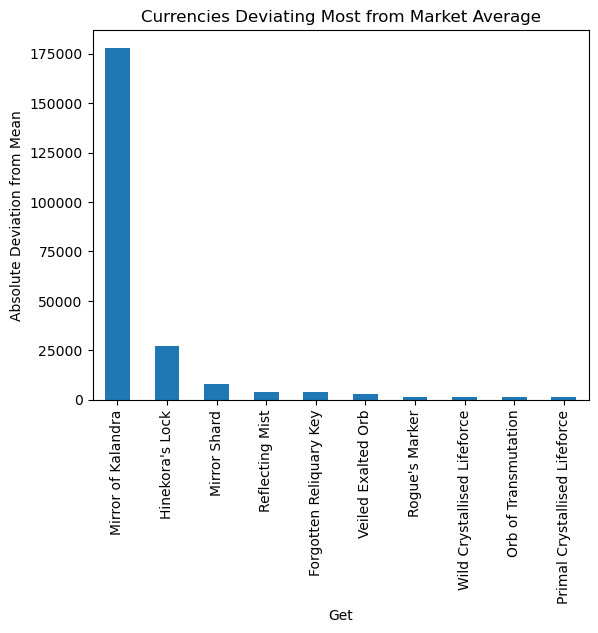

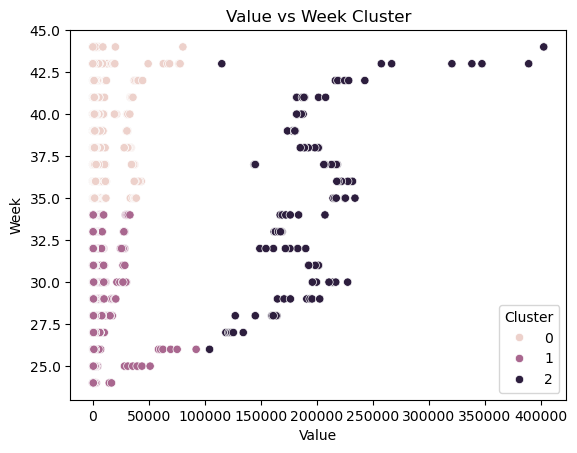

In [17]:
#Q3
df["Value_z"] = zscore(df["Value"])
# Outliers beyond ±3 std deviations
outliers = df[abs(df["Value_z"]) > 3]

overall_mean = df["Value"].mean()
currency_mean = df.groupby("Get")["Value"].mean()
currency_deviation = (currency_mean - overall_mean).abs().sort_values(ascending=False)
currency_deviation.head(10)

outliers["Get"].value_counts().head(10)
currency_deviation.head(10).plot(kind="bar")
plt.title("Currencies Deviating Most from Market Average")
plt.ylabel("Absolute Deviation from Mean")
plt.show()


kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(weekValue)


#cluster 1
features = df[["Value", "Week"]]
sns.scatterplot(data=df, x="Value", y="Week", hue="Cluster")
plt.xlabel("Value")
plt.ylabel("Week")
plt.title("Value vs Week Cluster")
plt.show()

## Hierarchical Clustering: Early vs Late Behavior

This section analyzes selected currencies using engineered features such as early value, late value, percentage change, and volatility.

After scaling the features, agglomerative (hierarchical) clustering is applied to group currencies with similar long-term behavior.

The resulting visualization helps compare how different currencies shift between early and late league stages and how they relate to each other in terms of growth and stability.

C:\Users\Nemo\AppData\Local\Temp\ipykernel_26912\876837096.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(features_scaled["Early"][i]+0.02, features_scaled["Late"][i]+0.02, features_scaled.index[i], fontsize=8)


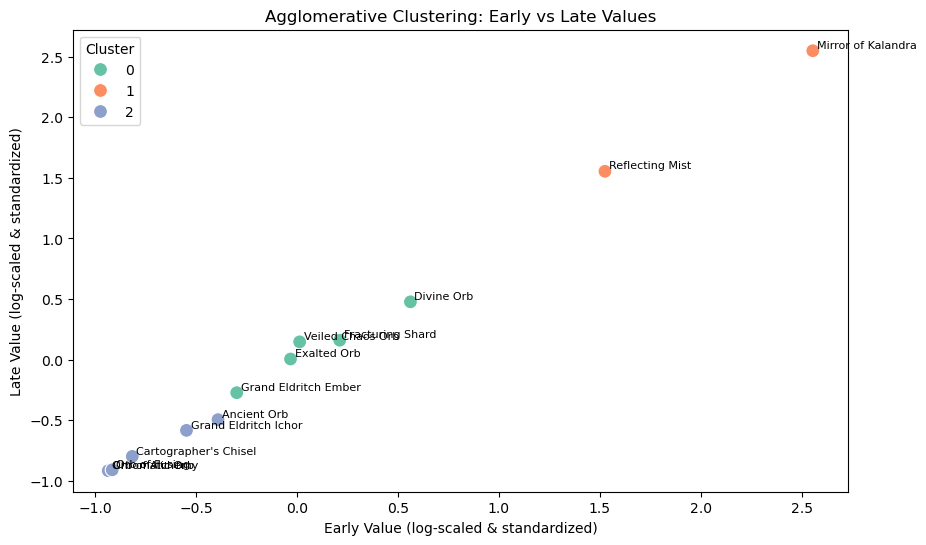

In [13]:
#cluster 2
from sklearn.cluster import DBSCAN

currency_stage_whitelist = currency_stage.loc[whitelist].copy()

features = pd.DataFrame({
    "Early": currency_stage_whitelist["Early"],
    "Late": currency_stage_whitelist["Late"],
    "PctChange": (currency_stage_whitelist["Late"] - currency_stage_whitelist["Early"]) / currency_stage_whitelist["Early"],
    "Volatility": df[df["Get"].isin(whitelist)].groupby("Get")["Value"].std()
}).fillna(0)

features.index.name = "Currency"
features.head()

features_log = features[["Early","Late","Volatility"]].apply(np.log1p)
features_log["PctChange"] = features["PctChange"]

# Scale to mean=0, std=1
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_log)
features_scaled = pd.DataFrame(scaled_features, columns=features_log.columns, index=features_log.index)

agg_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
features_scaled["AggCluster"] = agg_model.fit_predict(features_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(data=features_scaled, x="Early", y="Late", hue="AggCluster", palette="Set2", s=100)
for i in range(len(features_scaled)):
    plt.text(features_scaled["Early"][i]+0.02, features_scaled["Late"][i]+0.02, features_scaled.index[i], fontsize=8)
plt.xlabel("Early Value (log-scaled & standardized)")
plt.ylabel("Late Value (log-scaled & standardized)")
plt.title("Agglomerative Clustering: Early vs Late Values")
plt.legend(title="Cluster")
plt.show()